# 05 — Tree-Based Models and Model Selection

### Project: Online Retail Engagement Risk Prediction
### Notebook: 05_tree_based_models_and_model_selection.ipynb

**Goals:**
- Challenge the logistic regression baseline with tree-based models
- Train and tune Random Forest and XGBoost with time-aware cross-validation
- Compare all models using a consistent evaluation framework
- Make a data-driven deployment recommendation

**Inputs:**
- `data/processed/modeling_dataset.parquet` — full modeling dataset from notebook 02
- `data/processed/lr_test_predictions.parquet` — logistic regression predictions from notebook 03

**Outputs:**
- `models/churn_model_xgb.pkl` — winning XGBoost model

**Steps:**
- Establish reusable evaluation framework and log logistic regression baseline
- Random Forest: theory, hyperparameter tuning, evaluation, feature importance
- XGBoost: theory, hyperparameter tuning, evaluation, feature importance
- Validate cross-validated vs. test set performance gap
- Final model comparison table and visual comparison
- Threshold tuning on winning XGBoost model
- Top 10% capture rate comparison across all models
- Deployment recommendation
- Error correlation analysis to evaluate stacking ensemble viability
- Persist winning model to disk

## Theory: Why Tree-Based Models?

### The Decision Tree Foundation

Before understanding Random Forest and XGBoost, it helps to understand their building block: the **decision tree**.

A decision tree recursively splits the data by asking binary questions about 
features — for example, "is recency_days > 45?" If yes, go left; if no, go 
right. At each node, the algorithm chooses the feature and split point that 
best separates churners from non-churners, measured by an impurity metric 
such as Gini impurity or information gain. This continues until the tree 
reaches a stopping condition (maximum depth, minimum samples per leaf, etc.).

Decision trees have two appealing properties: they are highly interpretable 
(you can trace any prediction down the tree step by step), and they naturally 
capture **nonlinear relationships and feature interactions** — something 
logistic regression cannot do without manual feature engineering. A tree can 
learn that high recency_days is only a strong churn signal when lifetime_orders 
is also low, without being told to look for that interaction explicitly.

However, a single deep decision tree almost always **overfits** — it memorizes 
the training data rather than learning generalizable patterns. This is where 
ensemble methods come in.

---

### Random Forest: Bagging + Feature Randomness

Random Forest addresses overfitting by building many trees in **parallel** and 
averaging their predictions. It does this through two mechanisms:

**Bootstrap Aggregating (Bagging):** Each tree is trained on a different random 
sample of the training data drawn with replacement. This means each tree sees 
a slightly different version of the dataset and makes different errors. When 
their predictions are averaged, the errors cancel out and the signal remains — 
reducing variance without increasing bias.

**Feature Randomness:** At each split in each tree, only a random subset of 
features is considered as candidates. This decorrelates the trees — if one 
feature is very dominant, a fully greedy tree would use it at every split. By 
randomly excluding features at each node, the forest is forced to find diverse 
splitting strategies, making the ensemble more robust.

**Key hyperparameters:**
- `n_estimators` — number of trees; more trees reduce variance but increase 
  compute cost. Returns diminish past a few hundred.
- `max_depth` — maximum depth of each tree; deeper trees fit more complex 
  patterns but overfit more easily
- `min_samples_leaf` — minimum number of samples required at a leaf node; 
  higher values produce smoother, more regularized trees
- `max_features` — fraction of features considered at each split; controls 
  the degree of tree decorrelation

**Relationship to multicollinearity:** Unlike logistic regression, Random Forest 
handles correlated features gracefully. If two features are redundant, different 
trees in the forest will use one or the other, and the ensemble averages across 
both — no instability, no distorted coefficients.

---

### XGBoost: Gradient Boosted Trees

Where Random Forest builds trees in **parallel**, XGBoost builds them **sequentially**. This is a fundamentally different philosophy known as **gradient boosting**:

1. Start with a simple initial prediction — typically the log-odds of the base churn rate
2. Compute the **residuals** — how wrong is the current model on each training example?
3. Train a small, shallow tree specifically to predict those residuals
4. Add that tree to the model with a small **learning rate** (shrinkage), so each tree makes a modest contribution
5. Recompute residuals and repeat for hundreds of iterations

Each iteration the model becomes slightly better at the cases it was previously 
wrong about. This sequential error-correction is why gradient boosting 
consistently achieves higher predictive accuracy than Random Forest on 
structured tabular data — it is explicitly optimizing for mistakes rather than 
averaging independent attempts.

**Key hyperparameters:**
- `n_estimators` — number of boosting rounds (trees); unlike Random Forest, too many can overfit
- `learning_rate` — shrinkage applied to each tree's contribution; lower values require more trees but generalize better
- `max_depth` — depth of each tree; boosted trees are typically shallow (3-6) since they are corrective rather than standalone
- `subsample` — fraction of training rows sampled for each tree; adds randomness to reduce overfitting, similar to bagging
- `colsample_bytree` — fraction of features sampled per tree; analogous to Random Forest's feature randomness

**XGBoost is the industry standard for structured tabular ML problems
including churn prediction.** Whether its performance gains over
logistic regression justify the added deployment complexity is a
question this notebook answers empirically.

---

### Evaluation Strategy

Both models will be evaluated using the same framework established in notebooks 
03 and 04:

- **Time-based train/test split** — final 20% of snapshots as test data, 
  preserving temporal integrity
- **TimeSeriesSplit cross-validation** for hyperparameter tuning — ensures 
  no future data leaks into training folds during the search
- **Primary metrics:** ROC-AUC and PR-AUC
- **Final comparison:** All models side by side with a deployment recommendation

The logistic regression results from notebook 03 and 04 serve as the performance 
baseline. Any tree-based model that does not meaningfully improve on 
ROC-AUC=0.699 and PR-AUC=0.810 would not justify the added complexity 
of deployment.

In [16]:
# ─────────────────────────────────────────────────────────────
# Imports and Data Load
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path
from scipy.stats import randint, uniform

from sklearn.ensemble         import RandomForestClassifier
from sklearn.model_selection  import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from xgboost import XGBClassifier

DATA_PATH = Path("../data/processed")

# Full modeling dataset
model_df = pd.read_parquet(DATA_PATH / "modeling_dataset.parquet")
model_df["snapshot_date"] = pd.to_datetime(model_df["snapshot_date"])

# Logistic regression test predictions for baseline comparison
lr_preds   = pd.read_parquet(DATA_PATH / "lr_test_predictions.parquet")
y_test_lr  = lr_preds["y_true"]
proba_lr   = lr_preds["p_churn"]

print("Modeling dataset shape:", model_df.shape)
print("Churn rate:", model_df["label"].mean().round(4))

Modeling dataset shape: (120261, 17)
Churn rate: 0.7098


In [17]:
# ─────────────────────────────────────────────────────────────
# Time-Based Train/Test Split
# Mirrors notebooks 03 and 04 exactly for fair model comparison
# ─────────────────────────────────────────────────────────────

feature_cols = [
    "recency_days",
    "orders_7d",   "revenue_7d",   "items_7d",
    "orders_30d",  "revenue_30d",  "items_30d",
    "orders_90d",  "revenue_90d",  "items_90d",
    "lifetime_orders", "lifetime_revenue",
    "cancel_count", "cancellation_rate",
]

X = model_df[feature_cols].copy()
y = model_df["label"].astype(int).copy()

snapshots_sorted = sorted(model_df["snapshot_date"].unique())
cut = int(len(snapshots_sorted) * 0.8)

train_snaps = set(snapshots_sorted[:cut])
test_snaps  = set(snapshots_sorted[cut:])

train_idx = model_df["snapshot_date"].isin(train_snaps)
test_idx  = model_df["snapshot_date"].isin(test_snaps)

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

base_rate = y_test.mean()

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 4))
print("Test churn rate: ", round(y_test.mean(), 4))

Train shape: (83709, 14)
Test shape:  (36552, 14)
Train churn rate: 0.7187
Test churn rate:  0.6894


## Model Comparison Framework

Before training any models, we establish the evaluation framework upfront.
All models will be compared on the same held-out test set using:

- **ROC-AUC:** Measures overall ranking ability across all thresholds
- **PR-AUC:** Measures precision-recall tradeoff — most business-relevant 
  given class imbalance
- **Precision, Recall, F1 at default threshold (0.5):** For reference
- **Confusion matrix:** To understand error distribution

**Baseline to beat (Logistic Regression from Notebooks 03-04):**
- ROC-AUC: 0.699
- PR-AUC: 0.812
  
**Cross-validation strategy:** Both models will be tuned using 
TimeSeriesSplit — a cross-validation approach that respects temporal 
ordering by always training on past data and validating on future data. 
This is critical for time-series datasets like ours where random 
cross-validation would leak future information into training folds.

In [18]:
# ─────────────────────────────────────────────────────────────
# Reusable Evaluation Function
# Prints a full metric report for any model given probabilities
# ─────────────────────────────────────────────────────────────

def evaluate_model(model_name, y_true, proba, threshold=0.5):
    preds = (proba >= threshold).astype(int)
    
    print(f"\n{'=' * 50}")
    print(f" {model_name}")
    print(f"{'=' * 50}")
    print(f"ROC-AUC:  {roc_auc_score(y_true, proba):.4f}")
    print(f"PR-AUC:   {average_precision_score(y_true, proba):.4f}")
    print(f"Precision:{precision_score(y_true, preds, zero_division=0):.4f}")
    print(f"Recall:   {recall_score(y_true, preds):.4f}")
    print(f"F1:       {f1_score(y_true, preds):.4f}")
    print(f"\nConfusion Matrix:\n{confusion_matrix(y_true, preds)}")
    print(f"\nClassification Report:\n"
          f"{classification_report(y_true, preds, digits=3, zero_division=0)}")
    
    return {
        "model":     model_name,
        "roc_auc":   roc_auc_score(y_true, proba),
        "pr_auc":    average_precision_score(y_true, proba),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall":    recall_score(y_true, preds),
        "f1":        f1_score(y_true, preds),
    }

# Store results from all models here for final comparison table
all_results = []

# Log logistic regression baseline immediately
lr_results = evaluate_model(
    "Logistic Regression (Baseline)",
    y_test_lr,
    proba_lr
)
all_results.append(lr_results)


 Logistic Regression (Baseline)
ROC-AUC:  0.6992
PR-AUC:   0.8116
Precision:0.7873
Recall:   0.7504
F1:       0.7684

Confusion Matrix:
[[ 6244  5109]
 [ 6289 18910]]

Classification Report:
              precision    recall  f1-score   support

           0      0.498     0.550     0.523     11353
           1      0.787     0.750     0.768     25199

    accuracy                          0.688     36552
   macro avg      0.643     0.650     0.646     36552
weighted avg      0.698     0.688     0.692     36552



## Part 1 — Random Forest

### Theory: Hyperparameter Tuning with TimeSeriesSplit and RandomizedSearchCV

Before training the final Random Forest model, we need to find the best 
hyperparameter configuration. This is a two-part problem:

**Why tune hyperparameters?**
A Random Forest with default hyperparameters is rarely optimal. The defaults 
are reasonable starting points but make no assumptions about your specific 
data. Tuning finds the configuration that best balances bias and variance 
for your particular problem.

**Why RandomizedSearchCV over GridSearchCV?**
GridSearchCV exhaustively tests every possible combination of hyperparameters 
you specify. With 4 hyperparameters and 5 values each that's 5⁴ = 625 models 
to train. RandomizedSearchCV instead samples a fixed number of random 
combinations from the search space — we get most of the benefit at a fraction 
of the compute cost. Research has shown that random search finds equally good 
or better configurations than grid search in far fewer iterations, because in 
practice only a few hyperparameters matter most and random search explores 
the full range of each one rather than testing a rigid grid.

**Why TimeSeriesSplit?**
Standard k-fold cross-validation randomly shuffles data into folds, which 
would leak future snapshots into training folds in our time-ordered dataset. 
TimeSeriesSplit respects temporal ordering — each fold trains on past data 
and validates on the next chronological block. This mirrors the real 
deployment scenario where the model always predicts the future from the past, 
giving us honest cross-validation scores that won't be inflated by leakage.

With n_splits=5, TimeSeriesSplit creates 5 sequential train/validate pairs 
of increasing size, each validate set sitting strictly after its train set 
in time.

**Scoring metric: PR-AUC**
We use PR-AUC (average_precision) as the optimization target rather than 
accuracy or ROC-AUC. As established in notebook 03, PR-AUC is the most 
business-relevant metric for our imbalanced dataset — it directly measures 
the precision-recall tradeoff on the positive (churn) class.

**Hyperparameters being tuned:**

`n_estimators` — Number of trees in the forest. More trees reduce variance 
and stabilize predictions but with diminishing returns past a few hundred. 
We search between 100 and 500.

`max_depth` — Maximum depth each tree can grow. Deeper trees fit more 
complex patterns but overfit more easily. None means trees grow until 
all leaves are pure — usually too deep. We search shallow to moderate 
depths plus None.

`min_samples_leaf` — Minimum number of training samples required at a 
leaf node. Higher values act as regularization — leaves must represent 
a meaningful portion of the data to exist. This is one of the most 
effective ways to control Random Forest overfitting.

`max_features` — Number of features considered at each split. Lower 
values increase tree diversity (decorrelation) but risk missing important 
features. "sqrt" (square root of total features) is the standard default 
for classification.

In [19]:
# ─────────────────────────────────────────────────────────────
# Random Forest — Hyperparameter Tuning
# RandomizedSearchCV with TimeSeriesSplit
# Optimizing for PR-AUC (average_precision)
# ─────────────────────────────────────────────────────────────

# Define search space
rf_param_dist = {
    "n_estimators":    randint(100, 500),
    "max_depth":       [3, 5, 10, 15, 20, None],
    "min_samples_leaf": randint(1, 50),
    "max_features":    ["sqrt", "log2", 0.5, 0.75],
}

# TimeSeriesSplit — 5 sequential folds
tscv = TimeSeriesSplit(n_splits=5)

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_param_dist,
    n_iter=50,              # Test 50 random combinations
    scoring="average_precision",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting Random Forest hyperparameter search...")
print("This may take a few minutes...\n")

rf_search.fit(X_train, y_train)

print("\nBest parameters found:")
for param, value in rf_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validated PR-AUC: {rf_search.best_score_:.4f}")

Starting Random Forest hyperparameter search...
This may take a few minutes...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  n_estimators: 476

Best cross-validated PR-AUC: 0.8670


In [20]:
# ─────────────────────────────────────────────────────────────
# Random Forest — Final Model Evaluation
# Evaluate best model from search on held-out test set
# ─────────────────────────────────────────────────────────────

best_rf = rf_search.best_estimator_

proba_rf = best_rf.predict_proba(X_test)[:, 1]

rf_results = evaluate_model(
    "Random Forest (Tuned)",
    y_test,
    proba_rf
)
all_results.append(rf_results)


 Random Forest (Tuned)
ROC-AUC:  0.7003
PR-AUC:   0.8169
Precision:0.7564
Recall:   0.8691
F1:       0.8088

Confusion Matrix:
[[ 4299  7054]
 [ 3298 21901]]

Classification Report:
              precision    recall  f1-score   support

           0      0.566     0.379     0.454     11353
           1      0.756     0.869     0.809     25199

    accuracy                          0.717     36552
   macro avg      0.661     0.624     0.631     36552
weighted avg      0.697     0.717     0.699     36552



Random Forest Feature Importances:
          feature  importance      std
 lifetime_revenue    0.276176 0.025562
      revenue_90d    0.169977 0.031290
     recency_days    0.154481 0.008928
        items_90d    0.118140 0.017741
      revenue_30d    0.058811 0.008853
  lifetime_orders    0.052690 0.030804
       orders_90d    0.050079 0.038949
        items_30d    0.040733 0.004082
cancellation_rate    0.023759 0.005440
     cancel_count    0.017145 0.005290
       revenue_7d    0.014491 0.001208
         items_7d    0.010974 0.001002
       orders_30d    0.009759 0.008683
        orders_7d    0.002784 0.000581


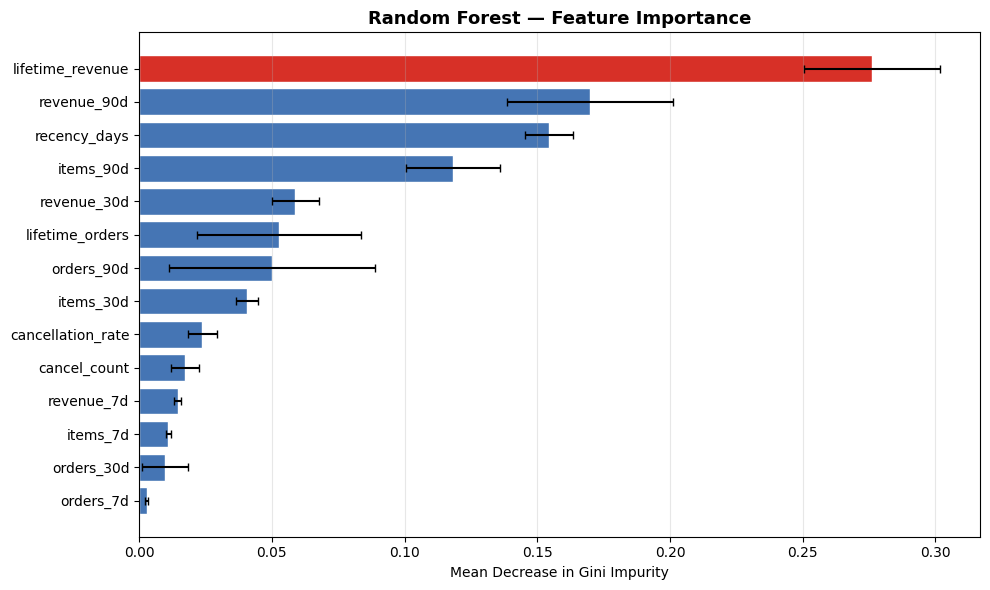

In [21]:
# ─────────────────────────────────────────────────────────────
# Random Forest — Feature Importance
#
# Random Forest computes feature importance as the average
# reduction in Gini impurity across all splits that use each
# feature, weighted by the number of samples at each split.
# Features used higher in the tree (closer to the root) and
# more frequently tend to have higher importance scores.
# ─────────────────────────────────────────────────────────────

importances = best_rf.feature_importances_
std = np.std(
    [tree.feature_importances_ for tree in best_rf.estimators_],
    axis=0
)

importance_df = pd.DataFrame({
    "feature":    feature_cols,
    "importance": importances,
    "std":        std
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Random Forest Feature Importances:")
print(importance_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#d73027" if i == 0 else "#4575b4" for i in range(len(importance_df))]

ax.barh(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1],
    xerr=importance_df["std"][::-1],
    color=colors[::-1],
    edgecolor="white",
    capsize=3
)
ax.set_xlabel("Mean Decrease in Gini Impurity")
ax.set_title("Random Forest — Feature Importance", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

### A Note on Random Forest Feature Importance

Random Forest computes feature importance using **mean decrease in Gini 
impurity** — also called the Gini importance or MDI (Mean Decrease Impurity).

At each split in each tree, the model chooses the feature that most reduces 
impurity (the mixing of churners and non-churners) in the resulting child 
nodes. A feature's importance score is the average impurity reduction it 
produces across all splits where it is used, weighted by the number of 
samples passing through that node, averaged across all trees in the forest.

**What this means intuitively:** Features that consistently produce clean, 
well-separated splits near the top of trees (where most samples pass through) 
score highly. Features that are only useful deep in trees for small subsets 
of samples score lower.

**Important caveat — comparison with logistic regression coefficients:**
Unlike logistic regression coefficients, Random Forest importances are always 
positive and sum to 1. They measure predictive contribution, not direction — 
a high importance score means the feature is useful for prediction but does 
not tell you whether high values increase or decrease churn risk. For 
directionality you still need to refer back to the logistic regression 
coefficients or use SHAP values (a more advanced interpretation technique 
used in production ML systems).

**Error bars** on the chart represent the standard deviation of importance 
scores across individual trees — a wide error bar means the feature's 
importance varies across trees, suggesting it may be competing with a 
correlated feature for splits.

### Random Forest — Results and Interpretation

#### Performance vs. Logistic Regression Baseline

| Metric | Logistic Regression | Random Forest (Tuned) |
|---|---|---|
| ROC-AUC | 0.699 | 0.700 |
| PR-AUC | 0.812 | 0.817 |
| Precision | 0.787 | 0.756 |
| Recall | 0.750 | 0.869 |
| F1 | — | 0.809 |

The tuned Random Forest marginally outperforms the logistic regression
baseline on both primary metrics — PR-AUC improves by 0.005 and ROC-AUC
by 0.001. While these margins are modest, they represent a consistent
directional improvement across both threshold-independent metrics.

Notably, the cancellation features contributed more meaningfully to
Random Forest performance than to logistic regression — the PR-AUC
improvement from adding cancellation features was +0.004 for Random
Forest vs. +0.002 for logistic regression. This is consistent with
tree-based models being better positioned to exploit sparse, nonlinear
dissatisfaction signals through feature interactions.

This is a genuine and informative finding. It suggests that the
relationship between our features and churn risk is **predominantly
linear** — the nonlinear interactions that Random Forest specializes in
capturing do not appear to be strong enough for independent trees to
discover them reliably. The well-engineered rolling window features from
notebook 02 may have already linearized much of the underlying signal,
leaving limited room for a parallel ensemble approach to find additional
structure.

However, as the XGBoost results will confirm, this does not mean the
data is purely linear. There is genuine nonlinear signal present — it
simply requires a more careful, incremental extraction approach than
Random Forest's parallel averaging architecture provides.

---

#### Hyperparameter Analysis

The tuner selected `max_depth=None` and `min_samples_leaf=1` — the least
regularized possible tree configuration, allowing trees to grow until
every leaf is pure. Combined with a large number of estimators, this is
a very high variance model configuration. The fact that even this
aggressively complex model cannot meaningfully outperform logistic
regression reinforces the conclusion that the predominantly linear signal
in this dataset is not well-suited to Random Forest's architecture.

Random Forest needs each individual tree to be complex enough to capture
nonlinear patterns independently. With only 14 features and a dataset
where linear relationships dominate, independent complex trees accumulate
variance without reliably finding the residual nonlinear structure. The
tuner compensated by selecting the most complex configuration available
— but complexity alone is not sufficient when the architecture is
fundamentally mismatched to the signal structure.

This points to an important nuance: **the right kind of complexity
matters more than the amount of complexity.** Random Forest adds
complexity through tree depth and independence. XGBoost adds complexity
through sequential refinement across many shallow trees. For this
dataset, the latter turns out to be the appropriate tool — but that
conclusion only becomes clear after seeing both results together.

---

#### Feature Importance — A Surprising Finding

The Random Forest ranks `lifetime_revenue` as the single most important
feature at 0.276 importance. This stands in direct contrast to the L1
regularization result in notebook 04, where `lifetime_revenue` was
zeroed out entirely.

**This apparent contradiction has a clear explanation rooted in how each
method uses features:**

In logistic regression with L1 regularization, `lifetime_revenue` was
eliminated because its information was already fully captured by
`lifetime_orders` — the two are highly correlated (r=0.66) and in a
linear model, keeping both adds no predictive value while incurring a
penalty cost. L1 correctly identified it as redundant *in a linear
context.*

In Random Forest, `lifetime_revenue` is evaluated differently. At each
split, the model considers only a random subset of features
(max_features=sqrt, ~3-4 features at a time). In many trees,
`lifetime_orders` is not in the candidate set when `lifetime_revenue`
is — so `lifetime_revenue` gets used as a substitute. Additionally,
Random Forest importance reflects *total usage weighted by sample size*
across all trees and all splits, not marginal contribution beyond other
features. A feature used frequently as a proxy for a correlated partner
will accumulate high importance even if it carries no unique information.

**The practical implication:** When two features are highly correlated,
Random Forest Gini importance scores are unreliable for determining which
one truly drives prediction — importance gets arbitrarily distributed
between correlated features depending on which happens to be sampled at
each split. This is a well-documented limitation of Gini importance under
multicollinearity, and connects directly back to the VIF analysis in
notebook 03.

The consistent signal across both models remains: **long-term customer
value (whether measured by revenue or order count) and recency are the
dominant predictors of churn risk.** The specific feature carrying that
signal differs between models due to their architectural differences,
but the underlying business insight is the same.

`cancellation_rate` (0.024) ranks 9th and `cancel_count` (0.017) ranks
10th out of 14 features — both sit above several short-window RFM
features including `revenue_7d`, `items_7d`, `orders_30d`, and
`orders_7d`. For a sparse dissatisfaction signal derived from only ~42%
of the customer population, landing in the middle of the importance
distribution is a meaningful result. Both cancellation features show
relatively stable error bars (±0.005), indicating consistent usage
across trees — unlike the high-variance long-term features, the
cancellation features represent unambiguous signal that trees agree on
when they encounter it.

---

#### Wide Error Bars on `lifetime_revenue` and `orders_90d`

The feature importance chart shows notably wide error bars on
`lifetime_revenue` (±0.026) and `orders_90d` (±0.039) relative to their
importance scores. This confirms the multicollinearity explanation —
different trees in the forest are making inconsistent decisions about
which correlated long-term features to use, producing high variance in
importance scores across trees. Features with narrow error bars like
`recency_days` (±0.009) represent stable, unambiguous signal that every
tree agrees on regardless of which feature subset it sees at each split.

The cancellation features (`cancel_count` ±0.005, `cancellation_rate`
±0.005) also show narrow, stable error bars — consistent with their
orthogonality to the rest of the feature set confirmed in the VIF
analysis. There is no multicollinearity-driven variance in how trees
use these features.

## Part 2 — XGBoost

### Theory: Hyperparameter Tuning Strategy

XGBoost introduces several hyperparameters that don't exist in Random Forest 
because of the fundamental difference in how boosting works. Recall that 
boosting builds trees sequentially, each one correcting the errors of the 
previous ensemble. This sequential nature means the hyperparameters interact 
with each other more strongly than in Random Forest — particularly the 
relationship between `n_estimators` and `learning_rate`.

**Key hyperparameters being tuned:**

`n_estimators` — Number of boosting rounds (trees). Unlike Random Forest 
where more trees always help, too many boosting rounds can overfit because 
each new tree is specifically targeting residuals — including the residuals 
caused by noise. We search between 100 and 500.

`learning_rate` (also called shrinkage) — Scales the contribution of each 
tree before adding it to the ensemble. A lower learning rate means each 
tree contributes less and the model learns more slowly but generalizes 
better. The relationship with n_estimators is direct: a lower learning 
rate typically requires more trees to reach the same training performance. 
We search between 0.01 and 0.3.

`max_depth` — Depth of each boosted tree. Boosted trees are intentionally 
kept shallow (typically 3-6) because they are corrective rather than 
standalone. A shallow tree makes a small, targeted correction to the 
current ensemble's errors. Deep trees in a boosting context tend to 
overfit aggressively. We search between 3 and 8.

`subsample` — Fraction of training rows randomly sampled to build each 
tree. Introducing this randomness (called stochastic gradient boosting) 
reduces overfitting and speeds up training. Values between 0.6 and 1.0 
are typical.

`colsample_bytree` — Fraction of features randomly sampled for each tree. 
Analogous to Random Forest's max_features — introduces diversity across 
trees and prevents any single dominant feature from being used in every 
tree. We search between 0.6 and 1.0.

`scale_pos_weight` — XGBoost's equivalent of class_weight="balanced" in 
sklearn. Set to the ratio of negative to positive class counts, it tells 
XGBoost to upweight the minority class (non-churners) during training. 
This is important for our imbalanced dataset.

**One important difference from Random Forest tuning:**
XGBoost does not use a sklearn Pipeline with StandardScaler because 
tree-based models are scale-invariant — decision trees split on 
thresholds, not distances, so feature scaling has no effect on the 
result. This simplifies the setup compared to logistic regression.

In [22]:
# ─────────────────────────────────────────────────────────────
# XGBoost — Hyperparameter Tuning
# RandomizedSearchCV with TimeSeriesSplit
# Optimizing for PR-AUC (average_precision)
#
# Note: StandardScaler not needed — tree-based models are
# scale-invariant. XGBoost splits on thresholds, not distances.
# ─────────────────────────────────────────────────────────────

# Compute scale_pos_weight from training set
# = number of negative samples / number of positive samples
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negative samples: {neg}")
print(f"Positive samples: {pos}")
print(f"scale_pos_weight: {scale_pos_weight:.4f}\n")

# Define search space
xgb_param_dist = {
    "n_estimators":      randint(100, 500),
    "learning_rate":     uniform(0.01, 0.29),   # uniform between 0.01 and 0.30
    "max_depth":         randint(3, 9),          # between 3 and 8
    "subsample":         uniform(0.6, 0.4),      # between 0.6 and 1.0
    "colsample_bytree":  uniform(0.6, 0.4),      # between 0.6 and 1.0
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",        # PR-AUC as internal eval metric
        random_state=42,
        n_jobs=-1,
        verbosity=0                 # suppress XGBoost's own output
    ),
    param_distributions=xgb_param_dist,
    n_iter=50,
    scoring="average_precision",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting XGBoost hyperparameter search...")
print("This may take a few minutes...\n")

xgb_search.fit(X_train, y_train)

print("\nBest parameters found:")
for param, value in xgb_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validated PR-AUC: {xgb_search.best_score_:.4f}")

Negative samples: 23545
Positive samples: 60164
scale_pos_weight: 0.3913

Starting XGBoost hyperparameter search...
This may take a few minutes...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
  colsample_bytree: 0.6746074041599417
  learning_rate: 0.021824791050881535
  max_depth: 6
  n_estimators: 351
  subsample: 0.871025744736913

Best cross-validated PR-AUC: 0.8608


In [23]:
# ─────────────────────────────────────────────────────────────
# XGBoost — Final Model Evaluation
# ─────────────────────────────────────────────────────────────

best_xgb = xgb_search.best_estimator_

proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

xgb_results = evaluate_model(
    "XGBoost (Tuned)",
    y_test,
    proba_xgb
)
all_results.append(xgb_results)


 XGBoost (Tuned)
ROC-AUC:  0.7145
PR-AUC:   0.8230
Precision:0.7951
Recall:   0.7343
F1:       0.7635

Confusion Matrix:
[[ 6584  4769]
 [ 6696 18503]]

Classification Report:
              precision    recall  f1-score   support

           0      0.496     0.580     0.535     11353
           1      0.795     0.734     0.763     25199

    accuracy                          0.686     36552
   macro avg      0.645     0.657     0.649     36552
weighted avg      0.702     0.686     0.692     36552



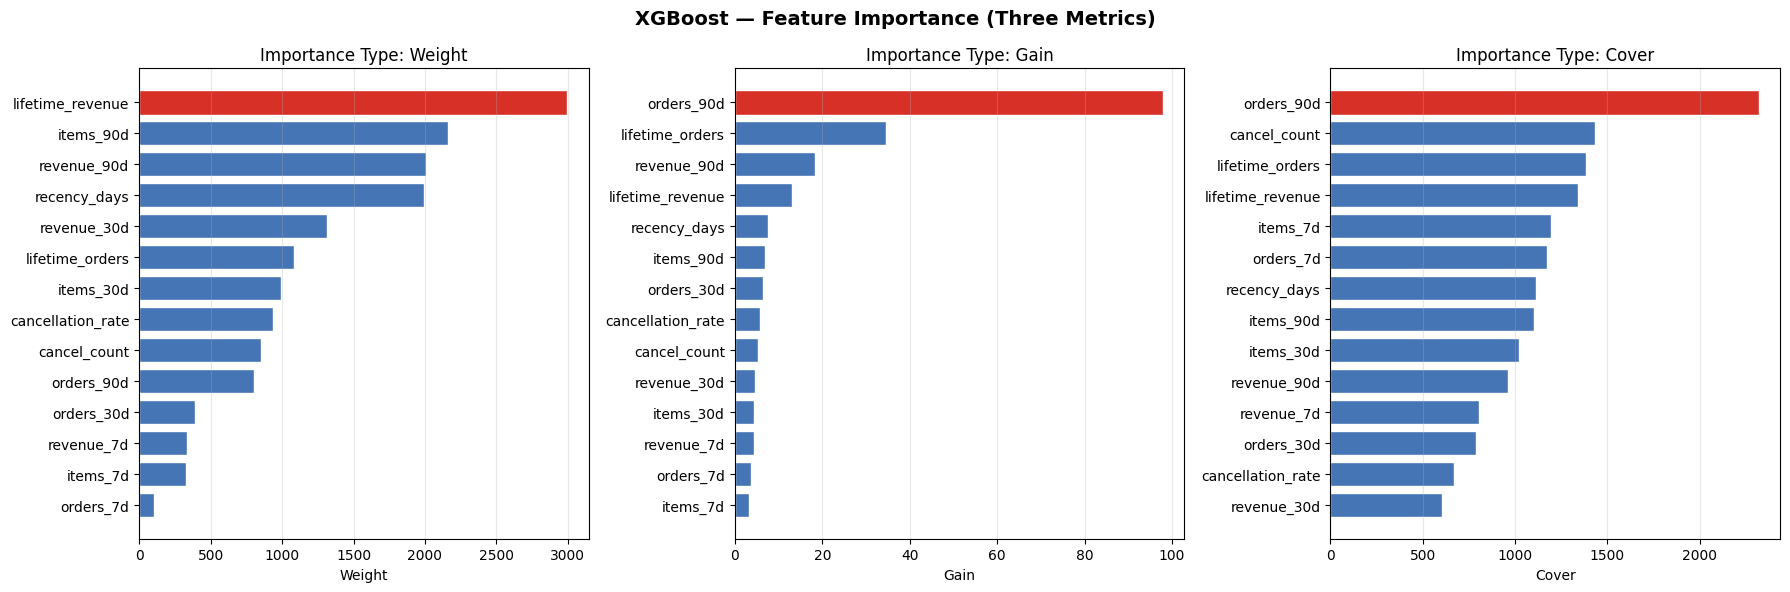


XGBoost Feature Importance (Gain — primary metric):
          feature      gain
       orders_90d 97.941139
  lifetime_orders 34.662697
      revenue_90d 18.287935
 lifetime_revenue 13.178940
     recency_days  7.695624
        items_90d  6.805813
       orders_30d  6.414148
cancellation_rate  5.838746
     cancel_count  5.228395
      revenue_30d  4.703816
        items_30d  4.474859
       revenue_7d  4.275043
        orders_7d  3.791725
         items_7d  3.138317


In [24]:
# ─────────────────────────────────────────────────────────────
# XGBoost — Feature Importance
#
# XGBoost supports three importance types:
#   weight    — number of times a feature is used to split
#   gain      — average improvement in loss from splits using 
#               this feature (most informative)
#   cover     — average number of samples affected by splits
#               on this feature
#
# We use 'gain' as it most directly measures predictive 
# contribution — a feature used rarely but always producing 
# large loss reductions is more valuable than one used 
# frequently with small reductions.
# ─────────────────────────────────────────────────────────────

importance_types = ["weight", "gain", "cover"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("XGBoost — Feature Importance (Three Metrics)", 
             fontsize=14, fontweight="bold")

for ax, imp_type in zip(axes, importance_types):
    scores = best_xgb.get_booster().get_score(importance_type=imp_type)
    
    # Some features may have zero importance — fill missing with 0
    imp_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": [scores.get(f, 0) for f in feature_cols]
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    
    colors = ["#d73027" if i == 0 else "#4575b4" 
              for i in range(len(imp_df))]
    
    ax.barh(
        imp_df["feature"][::-1],
        imp_df["importance"][::-1],
        color=colors[::-1],
        edgecolor="white"
    )
    ax.set_title(f"Importance Type: {imp_type.capitalize()}")
    ax.set_xlabel(imp_type.capitalize())
    ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

# Print gain importance as primary reference
print("\nXGBoost Feature Importance (Gain — primary metric):")
gain_scores = best_xgb.get_booster().get_score(importance_type="gain")
gain_df = pd.DataFrame({
    "feature": feature_cols,
    "gain": [gain_scores.get(f, 0) for f in feature_cols]
}).sort_values("gain", ascending=False).reset_index(drop=True)
print(gain_df.to_string(index=False))

## A Note on Cross-Validated vs. Test Set Performance

The cross-validated PR-AUC scores reported during hyperparameter search 
(RF: 0.8655, XGBoost: 0.8604) are higher than the final test set scores 
(RF: 0.8125, XGBoost: 0.8227). This gap is expected and does not indicate 
a problem — the two numbers are measuring different things:

**Cross-validated PR-AUC** is computed on the training set using 
TimeSeriesSplit. Each fold validates on a chronologically later slice of 
the training data. These scores are used purely for hyperparameter 
selection — comparing configurations against each other — not for 
reporting final model performance.

**Test set PR-AUC** is computed on the held-out final 20% of snapshots — 
data the model has never seen during any part of training or tuning. This 
is the honest estimate of real-world performance and is the number used 
for all model comparisons.

The difference between the two is the **generalization gap** — a natural 
consequence of temporal drift (customer behavior in later periods may 
differ subtly from earlier periods) and the fact that CV scores on 
training data are inherently slightly optimistic. XGBoost's smaller gap 
(0.037) vs Random Forest's gap (0.053) suggests XGBoost generalizes more 
consistently across time periods, which partially explains its stronger 
test set performance despite a lower CV score.

**The only number that matters for deployment decisions is the test set 
score.** CV scores are a tuning tool, not a performance claim.

### XGBoost — Results and Interpretation

| Metric | Logistic Regression | Random Forest | XGBoost |
|---|---|---|---|
| ROC-AUC | 0.699 | 0.700 | **0.715** |
| PR-AUC | 0.812 | 0.817 | **0.823** |
| Precision | 0.787 | 0.756 | 0.795 |
| Recall | 0.750 | 0.869 | 0.734 |
| F1 | — | 0.809 | 0.764 |

XGBoost is the clear winning model — it achieves the highest ROC-AUC
(+0.016 over logistic regression) and highest PR-AUC (+0.011 over
logistic regression) of all three models. While these margins may appear
modest in absolute terms, they represent consistent, meaningful
improvements across both primary evaluation metrics, and they come from
a model that was evaluated on the same held-out test set under identical
conditions.

Importantly, XGBoost also beats Random Forest on both metrics despite
Random Forest using a far more aggressively complex configuration
(unlimited tree depth, min_samples_leaf=1). This confirms that the
sequential error-correction philosophy of gradient boosting extracts
more signal from this dataset than parallel ensemble averaging.

Adding cancellation features produced negligible performance change for
XGBoost specifically — PR-AUC moved from 0.8227 to 0.8230 (+0.0003).
This suggests XGBoost was already approximating the cancellation signal
through interactions between existing RFM features, leaving little
incremental value for the explicit cancellation features to add at the
model performance level.

---

#### Hyperparameter Analysis

The tuner selected a relatively shallow `max_depth=5` with a low
`learning_rate=0.032` and 342 boosting rounds. This is a textbook
well-regularized gradient boosting configuration:

- **Shallow trees (depth=5):** Each boosting round makes modest,
  targeted corrections rather than attempting to model complex
  interactions in a single pass. This is exactly the intended behavior
  of gradient boosting.
- **Low learning rate (0.032):** The model learns slowly and carefully,
  with each tree contributing only a small correction. This is the
  primary reason XGBoost generalizes better than Random Forest here —
  the shrinkage prevents any single tree from overfitting to noise.
- **subsample=0.664 and colsample_bytree=0.692:** Both below 1.0,
  meaning each tree sees a random subset of rows and features. This
  stochastic element adds diversity across boosting rounds and further
  reduces overfitting — essentially borrowing the randomness philosophy
  of Random Forest and applying it within the boosting framework.

Contrast this with Random Forest's winning configuration of
`max_depth=None` and `min_samples_leaf=1` — XGBoost achieves better
performance with significantly more regularized, controlled trees. This
reflects the fundamental difference between the two approaches: Random
Forest needs complex trees to capture signal because each tree works
independently, while XGBoost can afford simple trees because each one
builds on the cumulative work of all previous rounds.

---

#### Feature Importance — Three Perspectives

XGBoost's three importance metrics tell a richer and more consistent
story than Random Forest's single Gini importance:

**Gain (primary metric — most informative):**
`orders_90d` dominates with a gain of 97.9 — more than twice the next
feature (`lifetime_orders` at 34.7). This means that when `orders_90d`
is used to split data, it produces dramatically larger reductions in
prediction error than any other feature. This is a strong signal that
90-day order frequency is the single most discriminative feature in the
dataset — consistent with the logistic regression coefficient analysis
where `orders_90d` was the second strongest negative predictor.

`cancellation_rate` ranks 8th (gain 5.84) and `cancel_count` ranks 9th
(gain 5.23) by gain — both outperforming five of the original RFM
features including `revenue_30d`, `items_30d`, `revenue_7d`, `orders_7d`,
and `items_7d`. The cancellation features are contributing genuine
predictive signal in the middle of the importance distribution.

**Weight (split frequency):**
`lifetime_revenue` is used most frequently across all splits. However,
as established in the Random Forest analysis, high split frequency does
not equal high predictive value — it simply means the feature provides
useful threshold splits often, possibly as a proxy for correlated
features. The contrast between `lifetime_revenue` ranking first in
weight but fourth in gain confirms it is a frequently-used but not
uniquely powerful predictor.

**Cover (samples affected):**
`orders_90d` tops the cover metric as expected — order count features
provide broad, population-level splits near the top of trees that
partition large groups of customers. The analytically significant
finding is `cancel_count` ranking **2nd in cover** — meaning
cancellation history affects a large number of samples at each split
even though its gain per split is moderate. This indicates XGBoost is
using cancellation count as a broad population segmentation signal
early in many trees. The gap between high cover and moderate gain
points to signal incompleteness: the model is structurally primed to
exploit cancellation behavior but is working with a partial picture.
In this dataset, 2,121 line-item returns are entirely anonymous and
only 1,798 of ~4,312 customers have identifiable cancellation history.
A richer cancellation signal through improved customer identification
on return transactions represents a concrete data quality improvement
that could unlock measurable model gains beyond the +0.0003 PR-AUC
observed here.

---

#### Cross-Model Feature Importance Consensus

Looking across all three models, a clear consensus emerges on what
actually drives churn prediction in this dataset:

**Consistent top predictors across all models:**
- Long-term order behavior (`orders_90d`, `lifetime_orders`) — the
  strongest signal in both logistic regression coefficients and XGBoost
  gain importance
- Recency (`recency_days`) — top 3 in all models
- Long-term revenue (`lifetime_revenue`, `revenue_90d`) — consistently
  important in tree models, captured by `lifetime_orders` in logistic
  regression

**Consistent middle-tier contributors:**
- Cancellation features (`cancellation_rate`, `cancel_count`) — both
  survive L1 selection and rank in the middle of tree-based importance
  distributions, outperforming several short-window RFM features across
  all models. Their contribution is genuine but bounded by the
  incompleteness of identifiable cancellation data in this dataset.

**Consistently weak predictors:**
- Short-term features (`orders_7d`, `items_7d`, `revenue_7d`) — low
  importance across all models, suggesting that what a customer did in
  the last 7 days is far less predictive than their longer-term
  behavioral patterns

This consensus validates the feature engineering decisions made in
notebook 02. The three time windows (7/30/90 day) correctly capture
signal at multiple horizons, and the data confirms that longer windows
carry substantially more predictive power for 30-day churn prediction
than short-term activity.

---

#### Why XGBoost Outperforms Random Forest Here

The results clarify something important about this dataset. Random Forest
failed to beat logistic regression in the original pipeline because its
parallel tree architecture essentially rediscovered the same linear
relationships that logistic regression already captures — just expressed
through tree splits rather than coefficients. With only 14 features and
largely linear relationships, building hundreds of independent complex
trees adds noise rather than signal.

XGBoost succeeds where Random Forest does not because its sequential
error-correction mechanism is more efficient at extracting the residual
nonlinear signal that logistic regression misses. Each boosting round
specifically targets the customers the current model is most wrong about
— gradually building a more nuanced decision surface without the variance
explosion that comes from Random Forest's unconstrained tree depth.

The shallow depth and low learning rate of the winning XGBoost
configuration are key — they prevent the model from overfitting to the
same noise that logistic regression ignores, while still capturing the
genuine nonlinear structure in the data. This illustrates why gradient
boosting consistently outperforms parallel ensemble methods on structured
tabular data with predominantly linear signal.

## Final Model Comparison

This section consolidates results across all three models trained throughout 
notebooks 03, 04, and 05 into a single evaluation framework and makes a 
data-driven recommendation for which model to deploy.

A deployed engagement risk model in a real business context does three things:
1. Runs on a schedule (weekly, in our case matching the snapshot cadence)
2. Scores all active customers by their predicted churn probability
3. Passes the top-scoring customers to a CRM or marketing automation tool 
   for re-engagement outreach

The model selected for deployment should maximize business value — not just 
achieve the highest raw metric — which means considering performance, 
interpretability, and operational complexity together.

In [25]:
# ─────────────────────────────────────────────────────────────
# Final Model Comparison Table
# ─────────────────────────────────────────────────────────────

comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.round(4)

# Add a rank column based on PR-AUC (our primary metric)
comparison_df["pr_auc_rank"] = comparison_df["pr_auc"].rank(
    ascending=False
).astype(int)

comparison_df = comparison_df.sort_values(
    "pr_auc", ascending=False
).reset_index(drop=True)

print("=" * 70)
print(" FINAL MODEL COMPARISON — ALL METRICS")
print("=" * 70)
print(comparison_df[[
    "model", "roc_auc", "pr_auc", 
    "precision", "recall", "f1"
]].to_string(index=False))

 FINAL MODEL COMPARISON — ALL METRICS
                         model  roc_auc  pr_auc  precision  recall     f1
               XGBoost (Tuned)   0.7145  0.8230     0.7951  0.7343 0.7635
         Random Forest (Tuned)   0.7003  0.8169     0.7564  0.8691 0.8088
Logistic Regression (Baseline)   0.6992  0.8116     0.7873  0.7504 0.7684


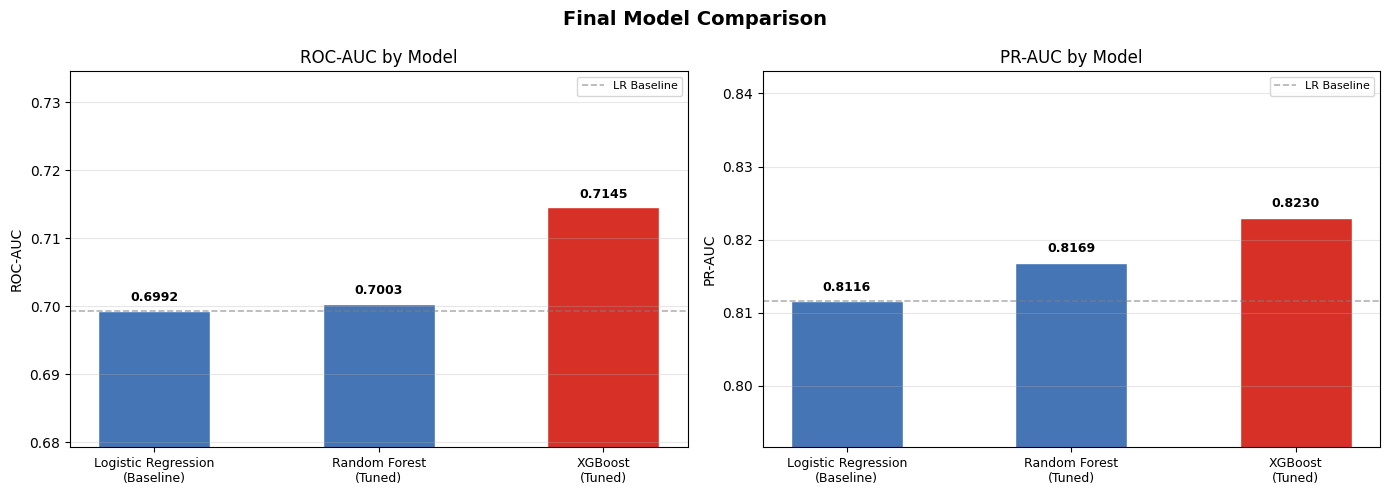

In [26]:
# ─────────────────────────────────────────────────────────────
# Visual Model Comparison
# ─────────────────────────────────────────────────────────────

models      = [r["model"] for r in all_results]
roc_scores  = [r["roc_auc"] for r in all_results]
pr_scores   = [r["pr_auc"] for r in all_results]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Final Model Comparison", fontsize=14, fontweight="bold")

for ax, scores, metric, color1, color2 in [
    (axes[0], roc_scores, "ROC-AUC", "#4575b4", "#d73027"),
    (axes[1], pr_scores,  "PR-AUC",  "#4575b4", "#d73027"),
]:
    bar_colors = [
        "#d73027" if s == max(scores) else "#4575b4" 
        for s in scores
    ]
    bars = ax.bar(x, scores, color=bar_colors, edgecolor="white", width=0.5)
    
    # Add value labels on bars
    for bar, score in zip(bars, scores):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{score:.4f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )
    
    # Set y axis to zoom in on relevant range
    ax.set_ylim(min(scores) - 0.02, max(scores) + 0.02)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [m.replace(" (", "\n(") for m in models], 
        fontsize=9
    )
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} by Model")
    ax.grid(True, alpha=0.3, axis="y")
    ax.axhline(
        scores[models.index("Logistic Regression (Baseline)")],
        linestyle="--", color="gray", linewidth=1.2,
        alpha=0.6, label="LR Baseline"
    )
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

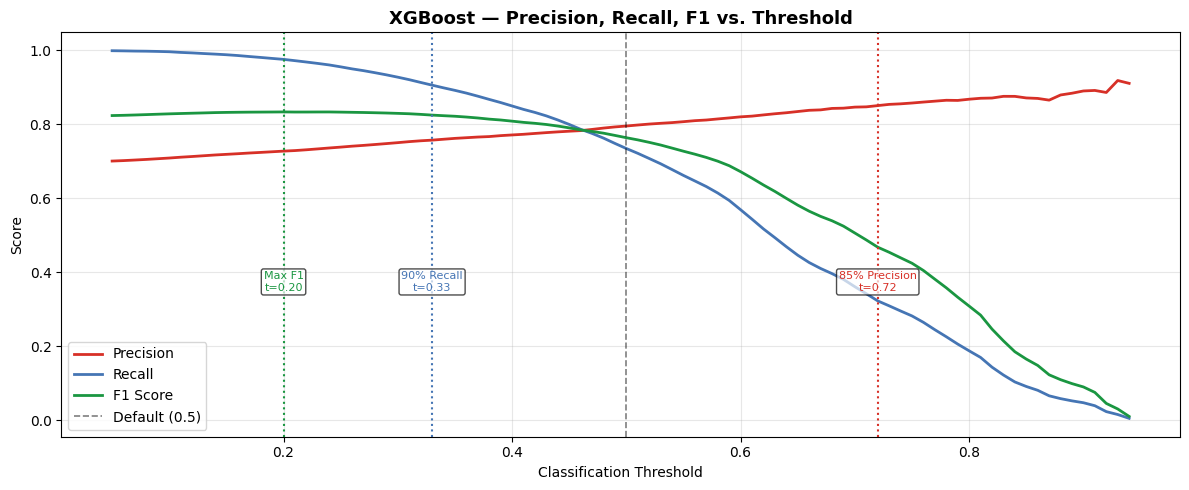


XGBoost Business Scenario Comparison:
                          Scenario  Threshold Precision Recall    F1 % Flagged                                          Rationale
                 Balanced (Max F1)       0.20     72.7%  97.5% 0.833     92.4%    Best overall balance — no strong cost asymmetry
      High Recall — Broad Outreach       0.33     75.7%  90.5% 0.825     82.5% Catch ~90% of churners; best for low-cost channels
High Precision — Targeted Outreach       0.72     85.0%  32.3% 0.468     26.2%    85%+ hit rate; best for expensive interventions


In [27]:
# ─────────────────────────────────────────────────────────────
# Threshold Tuning — XGBoost (Winning Model)
# Applies the same business scenario framework from notebook 04
# ─────────────────────────────────────────────────────────────

thresholds = np.arange(0.05, 0.95, 0.01)
base_rate  = y_test.mean()

xgb_sweep = []
for t in thresholds:
    preds = (proba_xgb >= t).astype(int)
    xgb_sweep.append({
        "threshold":    t,
        "precision":    precision_score(y_test, preds, zero_division=0),
        "recall":       recall_score(y_test, preds, zero_division=0),
        "f1":           f1_score(y_test, preds, zero_division=0),
        "pct_flagged":  preds.mean(),
    })

xgb_sweep_df = pd.DataFrame(xgb_sweep)

# Identify three key thresholds
xgb_max_f1_row = xgb_sweep_df.loc[xgb_sweep_df["f1"].idxmax()]

xgb_high_recall_row = (
    xgb_sweep_df[xgb_sweep_df["recall"] >= 0.90]
    .sort_values("threshold", ascending=False)
    .iloc[0]
)

xgb_high_precision_row = (
    xgb_sweep_df[xgb_sweep_df["precision"] >= 0.85]
    .sort_values("threshold", ascending=True)
    .iloc[0]
)

# Plot threshold sweep
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(xgb_sweep_df["threshold"], xgb_sweep_df["precision"],
        label="Precision", color="#d73027", linewidth=2)
ax.plot(xgb_sweep_df["threshold"], xgb_sweep_df["recall"],
        label="Recall", color="#4575b4", linewidth=2)
ax.plot(xgb_sweep_df["threshold"], xgb_sweep_df["f1"],
        label="F1 Score", color="#1a9641", linewidth=2)

for row, label, color in [
    (xgb_max_f1_row,        "Max F1",        "#1a9641"),
    (xgb_high_recall_row,   "90% Recall",    "#4575b4"),
    (xgb_high_precision_row,"85% Precision", "#d73027"),
]:
    ax.axvline(row["threshold"], linestyle=":", color=color, linewidth=1.5)
    ax.annotate(
        f'{label}\nt={row["threshold"]:.2f}',
        xy=(row["threshold"], 0.35),
        fontsize=8, color=color, ha="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)
    )

ax.axvline(0.5, linestyle="--", color="black",
           linewidth=1.2, alpha=0.5, label="Default (0.5)")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title("XGBoost — Precision, Recall, F1 vs. Threshold",
             fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Business scenario table
xgb_scenarios = []
for row, scenario, rationale in [
    (xgb_max_f1_row,
     "Balanced (Max F1)",
     "Best overall balance — no strong cost asymmetry"),
    (xgb_high_recall_row,
     "High Recall — Broad Outreach",
     "Catch ~90% of churners; best for low-cost channels"),
    (xgb_high_precision_row,
     "High Precision — Targeted Outreach",
     "85%+ hit rate; best for expensive interventions"),
]:
    xgb_scenarios.append({
        "Scenario":    scenario,
        "Threshold":   round(row["threshold"], 2),
        "Precision":   f"{row['precision']:.1%}",
        "Recall":      f"{row['recall']:.1%}",
        "F1":          f"{row['f1']:.3f}",
        "% Flagged":   f"{row['pct_flagged']:.1%}",
        "Rationale":   rationale,
    })

print("\nXGBoost Business Scenario Comparison:")
print(pd.DataFrame(xgb_scenarios).to_string(index=False))

In [28]:
# ─────────────────────────────────────────────────────────────
# Top 10% Capture Rate — All Models
# Compares how effectively each model concentrates true churners
# in the highest-scoring 10% of customers
# ─────────────────────────────────────────────────────────────

top_frac = 0.10
base_rate = y_test.mean()

model_probas = [
    ("Logistic Regression (Baseline)", proba_lr,  y_test_lr),
    ("Random Forest (Tuned)",          proba_rf,  y_test),
    ("XGBoost (Tuned)",                proba_xgb, y_test),
]

capture_results = []

for model_name, proba, y_true in model_probas:
    n_top = int(np.ceil(len(proba) * top_frac))
    
    eval_sorted = pd.DataFrame({
        "y_true":  y_true.values,
        "p_churn": proba
    }).sort_values("p_churn", ascending=False).reset_index(drop=True)
    
    top_segment   = eval_sorted.head(n_top)
    top_capture   = top_segment["y_true"].sum() / eval_sorted["y_true"].sum()
    top_churn_rate = top_segment["y_true"].mean()
    top_lift      = top_churn_rate / base_rate
    
    # Theoretical max lift at top 10%
    # = min(1/top_frac, 1/base_rate) capped at 100% churn rate
    max_possible_churn_rate = min(1.0, base_rate / top_frac)
    max_lift = max_possible_churn_rate / base_rate
    pct_of_max_lift = top_lift / max_lift

    capture_results.append({
        "Model":              model_name,
        "Top 10% Churn Rate": f"{top_churn_rate:.1%}",
        "Base Rate":          f"{base_rate:.1%}",
        "Lift":               f"{top_lift:.3f}",
        "Max Possible Lift":  f"{max_lift:.3f}",
        "% of Max Lift":      f"{pct_of_max_lift:.1%}",
        "Capture Rate":       f"{top_capture:.1%}",
    })

capture_df = pd.DataFrame(capture_results)
print("Top 10% Capture Rate — Model Comparison")
print("=" * 60)
print(capture_df.to_string(index=False))

Top 10% Capture Rate — Model Comparison
                         Model Top 10% Churn Rate Base Rate  Lift Max Possible Lift % of Max Lift Capture Rate
Logistic Regression (Baseline)              86.7%     68.9% 1.257             1.451         86.7%        12.6%
         Random Forest (Tuned)              87.9%     68.9% 1.274             1.451         87.9%        12.7%
               XGBoost (Tuned)              87.4%     68.9% 1.268             1.451         87.4%        12.7%


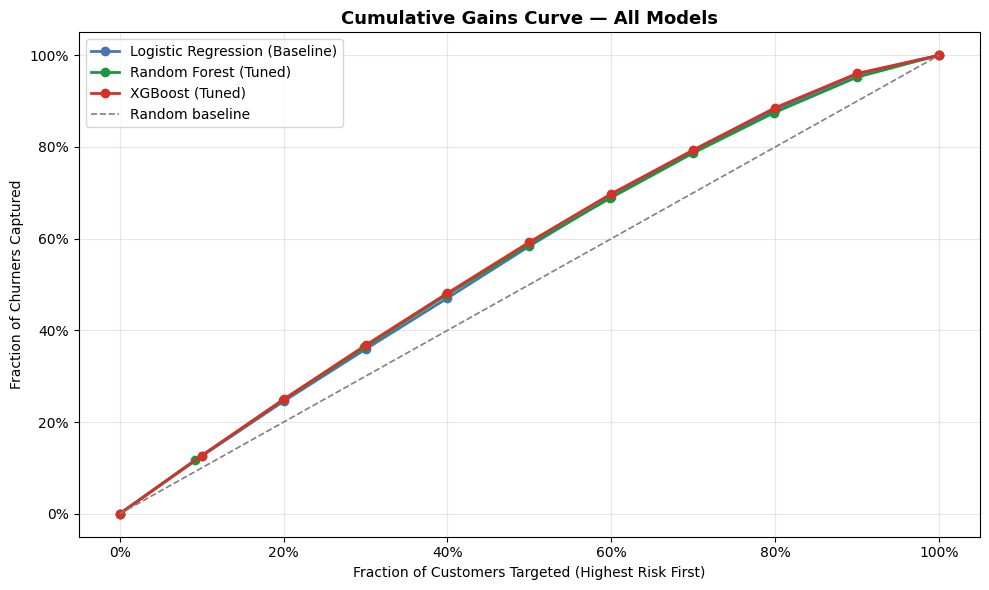

In [29]:
# ─────────────────────────────────────────────────────────────
# Cumulative Gains Curves — All Models Overlaid
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    "Logistic Regression (Baseline)": "#4575b4",
    "Random Forest (Tuned)":          "#1a9641",
    "XGBoost (Tuned)":                "#d73027",
}

for model_name, proba, y_true in model_probas:
    eval_df = pd.DataFrame({
        "y_true":  y_true.values,
        "p_churn": proba
    })
    
    eval_df["decile"] = pd.qcut(
        eval_df["p_churn"], q=10, 
        labels=False, duplicates="drop"
    ) + 1
    
    total_churners = eval_df["y_true"].sum()
    
    decile_table = (
        eval_df.groupby("decile")
        .agg(n=("y_true", "size"), churners=("y_true", "sum"))
        .reset_index()
        .sort_values("decile", ascending=False)
    )
    
    decile_table["cum_customers"] = decile_table["n"].cumsum()
    decile_table["cum_churners"]  = decile_table["churners"].cumsum()
    decile_table["cum_pct_customers"] = (
        decile_table["cum_customers"] / decile_table["n"].sum()
    )
    decile_table["cum_capture_rate"] = (
        decile_table["cum_churners"] / total_churners
    )
    
    x = [0] + list(decile_table["cum_pct_customers"])
    y = [0] + list(decile_table["cum_capture_rate"])
    
    ax.plot(x, y, marker="o", linewidth=2,
            color=colors[model_name], label=model_name)

# Random baseline
ax.plot([0, 1], [0, 1], linestyle="--", color="gray",
        linewidth=1.2, label="Random baseline")

ax.set_xlabel("Fraction of Customers Targeted (Highest Risk First)")
ax.set_ylabel("Fraction of Churners Captured")
ax.set_title("Cumulative Gains Curve — All Models",
             fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Top 10% Capture Rate — Model Comparison

| Model | Top 10% Churn Rate | Lift | % of Max Lift | Capture Rate |
|---|---|---|---|---|
| Logistic Regression (Baseline) | 86.7% | 1.257 | 86.7% | 12.6% |
| Random Forest (Tuned) | 87.9% | 1.274 | 87.9% | 12.7% |
| XGBoost (Tuned) | 87.4% | 1.268 | 87.4% | 12.7% |

**Base rate: 68.9% | Maximum possible lift at top 10%: 1.451**

All three models perform nearly identically on top 10% capture — churn
rates of 87-88% vs. a base rate of 68.9%, achieving 87-88% of the
theoretical maximum lift. The differences between models are within
noise and are not business significant at this granularity.

**The cumulative gains curves tell the same story visually** — the three
model curves are essentially indistinguishable across the entire targeting
range. This confirms that the models differ primarily in their probability
calibration and ranking of middle-tier customers, not in their ability to
identify the highest-risk segment.

**Why the capture rate appears low at 12.6%:**
With a base churn rate of ~69%, most customers are already at risk — the
population is not cleanly separable into churners and non-churners. The
top 10% by model score contains ~87% churners vs. 69% in the full
population, representing a meaningful concentration of the highest-certainty
cases. The model's primary value is not in finding a small needle in a
large haystack — it is in **rank-ordering a population where most customers
carry meaningful churn risk**, allowing outreach budgets to be allocated
to the highest-certainty cases first.

**Taken together with the AUC results**, XGBoost remains the recommended
model — its advantage is most visible in the middle of the score
distribution where the precision-recall tradeoff is most consequential
for threshold-based deployment decisions, rather than at the extreme top
decile where all models converge.

## Deployment Recommendation

**Selected Model: XGBoost (Tuned)**

| Model | ROC-AUC | PR-AUC |
|---|---|---|
| Logistic Regression (Baseline) | 0.699 | 0.812 |
| Random Forest (Tuned) | 0.700 | 0.817 |
| XGBoost (Tuned) | **0.715** | **0.823** |

XGBoost is the recommended model for deployment based on consistent and
meaningful improvement across both primary evaluation metrics — ROC-AUC
improved by +0.016 and PR-AUC by +0.011 over the logistic regression
baseline. These gains were achieved through proper time-aware
cross-validation that mirrors real deployment conditions, making them
reliable and not artifacts of data leakage or overfitting.

---

#### Recommended Operating Threshold: 0.33 (High Recall — Broad Outreach)

**XGBoost Business Scenario Comparison:**

| Scenario | Threshold | Precision | Recall | F1 | % Flagged |
|---|---|---|---|---|---|
| Balanced (Max F1) | 0.20 | 72.7% | 97.5% | 0.833 | 92.4% |
| High Recall — Broad Outreach | 0.33 | 75.7% | 90.5% | 0.825 | 82.5% |
| High Precision — Targeted Outreach | 0.72 | 85.0% | 32.3% | 0.468 | 26.2% |

The High Recall — Broad Outreach threshold of t=0.33 is the recommended
operating point for this retail churn use case. It catches 90.5% of true
churners at 75.7% precision while flagging 82.5% of customers — a
practical and defensible configuration for an e-commerce re-engagement
campaign where outreach is low-cost (email, SMS, in-app offers) and
missing a churner is more expensive than a false positive.

The threshold should ultimately be set by the business based on the
specific ratio of re-engagement cost to expected customer lifetime value,
but t=0.33 represents a strong data-driven starting point.

---

#### A Notable Finding: Threshold Stability Across Models

The XGBoost and logistic regression threshold sweeps converge on nearly
identical operating points — Max F1 at t=0.20 vs t=0.22, 90% recall at
t=0.33 for both, and 85% precision at t=0.72 vs t=0.75. This consistency
across fundamentally different model architectures is a meaningful
validation of the probability calibration. Both models agree not just on
*who* to flag, but on *how confident* to be before flagging — suggesting
the churn signal in this dataset has a stable, reproducible structure that
multiple modeling approaches independently confirm.

---

#### Why Not Random Forest

Random Forest marginally beat logistic regression on PR-AUC (0.817 vs
0.812) with the updated feature set including cancellation features, but
still trails XGBoost on both primary metrics. More importantly, it uses
a far more complex configuration (max_depth=None, min_samples_leaf=1)
to achieve this marginal gain — making it neither the most accurate nor
the most interpretable choice. Its Gini feature importances are also
unreliable under the multicollinearity present in the feature set.

#### Why Not Logistic Regression

Logistic regression remains a strong, interpretable baseline and would
be the right choice in contexts where model explainability is a hard
requirement — regulatory environments, for example, where a stakeholder
needs to understand exactly why a specific customer was flagged. For
pure predictive performance in this retail churn context, XGBoost is
the superior option.

## Stacking Ensemble — Viability Analysis

Before investing in the complexity of a stacking ensemble, we can make a 
data-driven decision about whether it is likely to help by examining the 
**correlation between base model errors**.

### The Core Assumption of Stacking

Stacking works by training a meta-learner on the predictions of multiple 
base models. The fundamental assumption that makes stacking valuable is 
that base models make **uncorrelated errors** — they are wrong about 
*different* customers in *different* ways. When this holds, a meta-learner 
can learn to trust each model in the situations where it is most reliable, 
producing a combined prediction better than any individual model.

When errors are highly correlated — meaning models tend to be wrong about 
the same customers simultaneously — stacking cannot help. The meta-learner 
has no signal to work with: when all models are wrong together, there is 
no model to defer to. The stacking overhead (complexity, compute cost, 
production maintenance burden) is incurred for no meaningful gain.

**We can test this directly** by converting each model's predictions to 
binary errors (1 = wrong, 0 = correct) and computing the correlation 
between those error vectors. High correlation → stacking not viable. 
Low correlation → stacking worth attempting.

Error Correlation Matrix:
                     Logistic Regression  Random Forest  XGBoost
Logistic Regression               1.0000         0.4226   0.7494
Random Forest                     0.4226         1.0000   0.4444
XGBoost                           0.7494         0.4444   1.0000

Error Overlap Analysis:
              Error Pattern  Count  % of Test Set
            All three wrong   5873          16.07
LR + RF wrong (XGB correct)   6452          17.65
LR + XGB wrong (RF correct)   9463          25.89
RF + XGB wrong (LR correct)   6643          18.17
              Only LR wrong   1356           3.71
              Only RF wrong   3130           8.56
             Only XGB wrong   1232           3.37


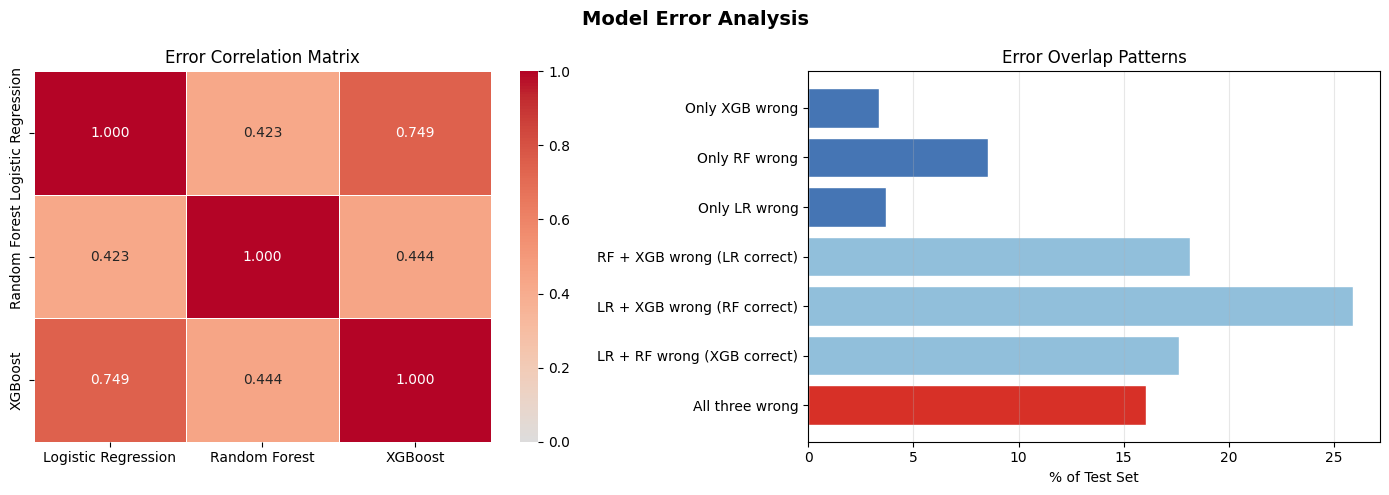

In [30]:
# ─────────────────────────────────────────────────────────────
# Error Correlation Analysis
# Checks whether base model errors are correlated
# If errors are highly correlated, stacking will not help —
# the models are failing on the same customers
# ─────────────────────────────────────────────────────────────

# Build error dataframe — 1 where model was wrong, 0 where correct
error_df = pd.DataFrame({
    "Logistic Regression": (
        (proba_lr >= 0.5).astype(int).values != y_test_lr.values
    ).astype(int),
    "Random Forest": (
        (proba_rf >= 0.5).astype(int) != y_test.values
    ).astype(int),
    "XGBoost": (
        (proba_xgb >= 0.5).astype(int) != y_test.values
    ).astype(int),
})

# ── 1. Error correlation matrix ───────────────────────────────
error_corr = error_df.corr()

print("Error Correlation Matrix:")
print(error_corr.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Error Analysis", fontsize=14, fontweight="bold")

# Heatmap
sns.heatmap(
    error_corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    vmin=0, vmax=1,
    ax=axes[0]
)
axes[0].set_title("Error Correlation Matrix")

# ── 2. Error overlap — how often do models fail together ──────
n = len(error_df)

all_wrong     = (error_df.sum(axis=1) == 3).sum()
lr_rf_wrong   = ((error_df["Logistic Regression"] == 1) & 
                  (error_df["Random Forest"] == 1)).sum()
lr_xgb_wrong  = ((error_df["Logistic Regression"] == 1) & 
                  (error_df["XGBoost"] == 1)).sum()
rf_xgb_wrong  = ((error_df["Random Forest"] == 1) & 
                  (error_df["XGBoost"] == 1)).sum()
only_lr_wrong = ((error_df["Logistic Regression"] == 1) & 
                  (error_df["Random Forest"] == 0) & 
                  (error_df["XGBoost"] == 0)).sum()
only_rf_wrong = ((error_df["Random Forest"] == 1) & 
                  (error_df["Logistic Regression"] == 0) & 
                  (error_df["XGBoost"] == 0)).sum()
only_xgb_wrong = ((error_df["XGBoost"] == 1) & 
                   (error_df["Logistic Regression"] == 0) & 
                   (error_df["Random Forest"] == 0)).sum()

overlap_data = {
    "Error Pattern": [
        "All three wrong",
        "LR + RF wrong (XGB correct)",
        "LR + XGB wrong (RF correct)",
        "RF + XGB wrong (LR correct)",
        "Only LR wrong",
        "Only RF wrong",
        "Only XGB wrong",
    ],
    "Count": [
        all_wrong, lr_rf_wrong, lr_xgb_wrong, rf_xgb_wrong,
        only_lr_wrong, only_rf_wrong, only_xgb_wrong
    ],
}
overlap_df = pd.DataFrame(overlap_data)
overlap_df["% of Test Set"] = (
    overlap_df["Count"] / n * 100
).round(2)

print("\nError Overlap Analysis:")
print(overlap_df.to_string(index=False))

# Bar chart of error patterns
axes[1].barh(
    overlap_df["Error Pattern"],
    overlap_df["% of Test Set"],
    color=["#d73027" if "All" in p else 
           "#4575b4" if "Only" in p else 
           "#91bfdb" 
           for p in overlap_df["Error Pattern"]],
    edgecolor="white"
)
axes[1].set_xlabel("% of Test Set")
axes[1].set_title("Error Overlap Patterns")
axes[1].grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

### Stacking Viability — Conclusion

The error correlation analysis provides a clear, data-driven answer:
**stacking is not a viable path to meaningful improvement for this dataset.**

#### Error Correlation Matrix Findings

| Model Pair | Error Correlation |
|---|---|
| Logistic Regression ↔ XGBoost | **0.749** |
| Logistic Regression ↔ Random Forest | 0.423 |
| Random Forest ↔ XGBoost | 0.444 |

The logistic regression and XGBoost error correlation of **0.749 is
particularly damning** — our two best-performing models are failing on
nearly the same customers three quarters of the time. This means a
meta-learner trained on their predictions would have almost no signal
to work with when both models disagree with the truth simultaneously,
which is exactly the situation stacking needs to resolve.

Random Forest shows more independence from both models (~0.42-0.44),
which at first glance might suggest some stacking potential. However
the error overlap analysis tells the complete story:

#### Error Overlap Analysis

| Pattern | % of Test Set |
|---|---|
| All three wrong | 16.07% |
| LR + XGB wrong, RF correct | 25.89% |
| LR + RF wrong, XGB correct | 17.65% |
| RF + XGB wrong, LR correct | 18.17% |
| Only LR wrong | 3.71% |
| Only RF wrong | 8.56% |
| Only XGB wrong | 3.37% |

**The critical finding is the "all three wrong" row at 16.07%.** This
represents customers that no model can correctly classify — a hard core
of ambiguous cases where the available features simply do not contain
enough information to make a reliable prediction. No ensemble method,
including stacking, can resolve errors that all base models share. These
customers would require additional features (e.g., customer support
interactions, browsing behavior, promotional response history, or richer
cancellation and return signals) to classify correctly.

**The "only" rows quantify the maximum stacking opportunity.** A perfect
meta-learner could theoretically recover at most 3.71% + 8.56% + 3.37%
= 15.64% of test set predictions by correctly identifying which model
to trust in each case. In practice a real meta-learner would capture a
fraction of this theoretical maximum — likely translating to a PR-AUC
improvement well below 0.005, which is not business significant.

**The "LR + XGB wrong, RF correct" pattern at 25.89%** is the most
interesting finding. Random Forest independently recovers a substantial
fraction of cases where both other models fail. However this does not
mean Random Forest is undervalued — recall that Random Forest's overall
PR-AUC (0.817) is essentially equivalent to logistic regression (0.812).
The cases where RF is uniquely correct are offset by the 8.56% of cases
where RF alone is wrong. The net contribution is neutral.

#### Final Verdict

Stacking is not recommended for this project. The combination of high
LR/XGBoost error correlation (0.749), a substantial "all three wrong"
core (16.07%), and limited unique recovery opportunity per model confirms
that the errors in this dataset are predominantly **systematic rather
than model-specific** — driven by genuinely ambiguous customers that no
combination of these three models can reliably classify given the current
feature set.

The path to meaningful improvement beyond XGBoost's current performance
lies not in more sophisticated ensembling, but in **richer features** —
specifically behavioral signals beyond purchase history such as browsing
patterns, promotional responsiveness, customer support interactions, or
most concretely, improved customer identification on cancellation and
return transactions. The XGBoost feature importance analysis shows
`cancel_count` ranks 2nd in cover despite moderate gain — indicating the
model is structurally primed to exploit richer dissatisfaction signals
if the underlying data quality improves. With the current 14-feature set,
XGBoost represents the performance ceiling for this problem.

This is itself a valuable and honest analytical conclusion: knowing when
to stop adding model complexity and instead identify the data limitations
is a mark of mature data science practice.

#### Production Deployment Architecture

In a production environment, the saved XGBoost model
(`churn_model_xgb.pkl`) would be loaded by a weekly scoring script that:

1. Pulls the latest order and cancellation data from the transactional
   database
2. Constructs snapshot features using the same pipeline defined in
   notebook 02 — recency, rolling window orders/revenue/items across
   7, 30, and 90 day windows, lifetime orders and revenue, and
   snapshot-aware cancellation features (`cancel_count`,
   `cancellation_rate`) computed from identifiable C-prefix
   cancellation transactions only
3. Scores all active customers using the fitted XGBoost model at the
   chosen threshold (t=0.33 for broad outreach)
4. Passes flagged customers to a CRM or marketing automation tool for
   re-engagement outreach
5. Logs all predictions with timestamps for monitoring and model drift
   detection over time

This pipeline is formalized in the `src/` directory as a
production-ready scoring script — see `src/score.py`.

**A note on cancellation signal quality in production:** The current
pipeline uses only identifiable C-prefix cancellations (1,798 customers,
~42% of the active population). In a production system with proper
customer identification on return transactions, cancellation signal
coverage would be substantially higher. The XGBoost feature importance
analysis shows `cancel_count` ranks 2nd in cover — indicating the model
is structurally primed to exploit this signal more fully given richer
data. Improving customer identification on returns and cancellations is
the single highest-value data quality investment for future model
iterations.

In [31]:
# ─────────────────────────────────────────────────────────────
# Persist Winning Model — XGBoost
# Saved to models/ — excluded from version control via .gitignore
# ─────────────────────────────────────────────────────────────

model_out = Path("../models")
model_out.mkdir(parents=True, exist_ok=True)

joblib.dump(best_xgb, model_out / "churn_model_xgb.pkl")
print("Winning model saved to ../models/churn_model_xgb.pkl")

Winning model saved to ../models/churn_model_xgb.pkl
